#**EXP-5A PSK**
#**NAME:VARSHINI M**
#**REGNO:212224060293**

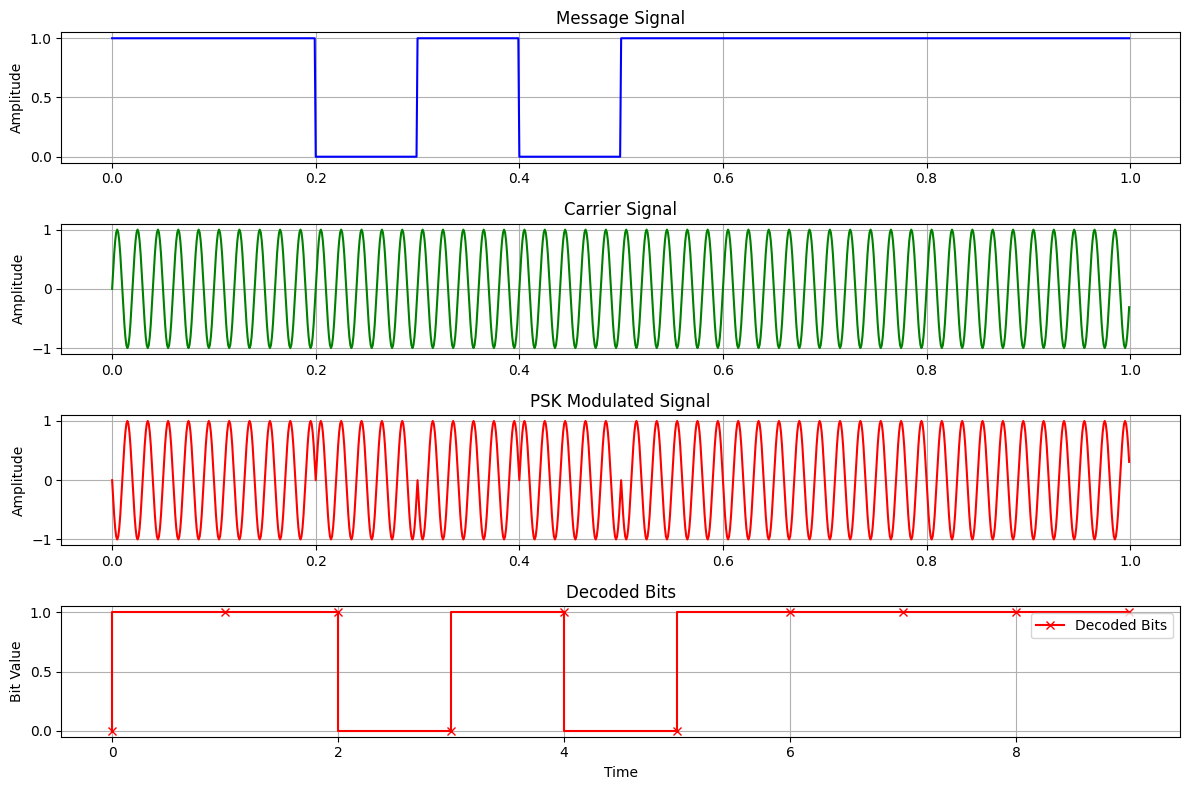

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
# Butterworth low-pass filter for demodulation
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)
# Parameters
fs = 1000                # Sampling frequency
f_carrier = 50           # Carrier frequency
bit_rate = 10            # Data rate (bits per second)
T = 1                    # Total time duration in seconds
t = np.linspace(0, T, int(fs * T), endpoint=False)
# Message signal (binary data)
bits = np.random.randint(0, 2, bit_rate)
bit_duration = fs // bit_rate
message_signal = np.repeat(bits, bit_duration)
# PSK Modulation (0 -> 0 phase, 1 -> 180° phase shift)
carrier = np.sin(2 * np.pi * f_carrier * t)
psk_signal = np.sin(2 * np.pi * f_carrier * t + np.pi * message_signal)
# PSK Demodulation
demodulated = psk_signal * carrier
filtered_signal = butter_lowpass_filter(demodulated, f_carrier, fs)
decoded_bits = (filtered_signal[::bit_duration] < 0).astype(int)
# Plotting
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(t, message_signal, label='Message Signal (Binary)', color='b')
plt.title('Message Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.subplot(4, 1, 2)
plt.plot(t, carrier, label='Carrier Signal', color='g')
plt.title('Carrier Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.subplot(4, 1, 3)
plt.plot(t, psk_signal, label='PSK Modulated Signal', color='r')
plt.title('PSK Modulated Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.subplot(4, 1, 4)
plt.step(np.arange(len(decoded_bits)), decoded_bits, label='Decoded Bits', color='r', marker='x')
plt.title('Decoded Bits')
plt.xlabel('Time')
plt.ylabel('Bit Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()